# 1. Numerical Derivative & Integration

This section focuses on two fundamental concepts in calculus: **numerical differentiation** and **numerical integration**. These concepts allow us to approximate derivatives and integrals of functions using discrete data points, which is especially useful when dealing with experimental or computational data.

## Key Concepts

### Numerical Derivative
- The derivative of a function gives the rate of change of the function with respect to its variable.
- For discrete data, we approximate the derivative using the formula:

$$
\text{Derivative at } x_i \approx \frac{f(x_{i+1}) - f(x_i)}{x_{i+1} - x_i}
$$

### Numerical Integration
- Integration gives the total area under a curve, or the accumulated value of the function over a range.
- For discrete data, we can approximate the integral using the **trapezoidal rule**:


$$
\text{Integral } \approx \sum_{i} f(x_i) \cdot \Delta x
$$

---
In this chapter, we will:
1. Load and visualize a sine wave dataset.
2. Calculate the numerical derivative of the sine wave.
3. Calculate the numerical integral of the sine wave.
4. Explore how noise in data affects differentiation and integration.


In [2]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1.1 Load and Visualize the Sine Wave Data

- The dataset contains a sine wave (`sin`) as well as a noisy sine wave (`sin_noise`).
- Time values are stored in the `ts` column.
- First, we will load the data, adjust the time to start from 0, and plot the sine wave to visualize it.

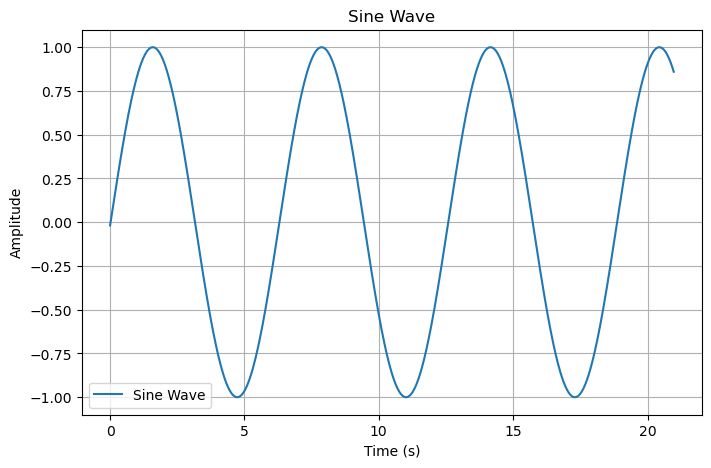

In [3]:
# Load the sine wave dataset from a CSV file
data = pd.read_csv('cos_sin.csv')  # Replace with your file path
ts = data['ts'].values
ts = ts - ts[0]  # Adjust time to start at 0
sin = data['sin'].values

# Plot the sine wave
plt.figure(figsize=(8, 5))
plt.plot(ts, sin, label='Sine Wave')
plt.title('Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

### 1.2 Numerical Derivative of the Sine Wave

- Using the forward difference formula, we approximate the derivative of the sine wave.
- Note: The first derivative value is set to 0 as there is no previous data point for calculation.

The expected result for the derivative of `sin(x)` is `cos(x)`.

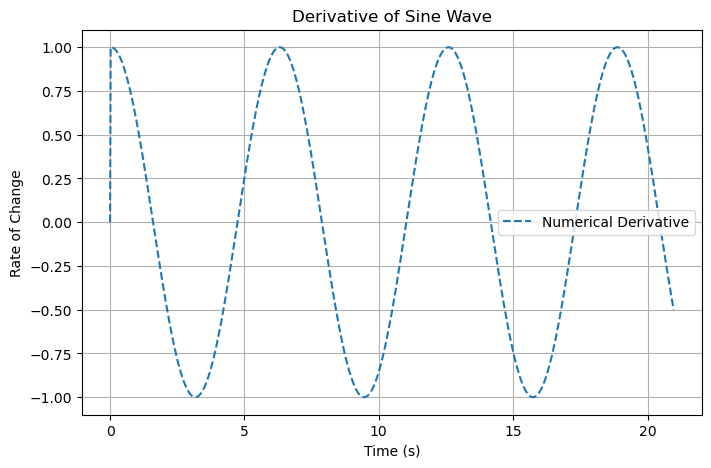

In [4]:
# Calculate the numerical derivative of the sine wave
dsin = np.zeros(len(sin))  # Initialize the derivative array with zeros
for i in range(1, len(sin)):
    # Compute the difference quotient for each time step
    dsin[i] = (sin[i] - sin[i-1]) / (ts[i] - ts[i-1])

# Plot the derivative
plt.figure(figsize=(8, 5))
plt.plot(ts, dsin, '--', label='Numerical Derivative')
plt.title('Derivative of Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Rate of Change')
plt.grid(True)
plt.legend()
plt.show()

### 1.3 Numerical Integration of the Sine Wave

- Using the trapezoidal rule, we approximate the integral of the sine wave.
- The integral at the first data point is initialized to 0.

The expected result for the integral of `sin(x)` is `-cos(x)`.

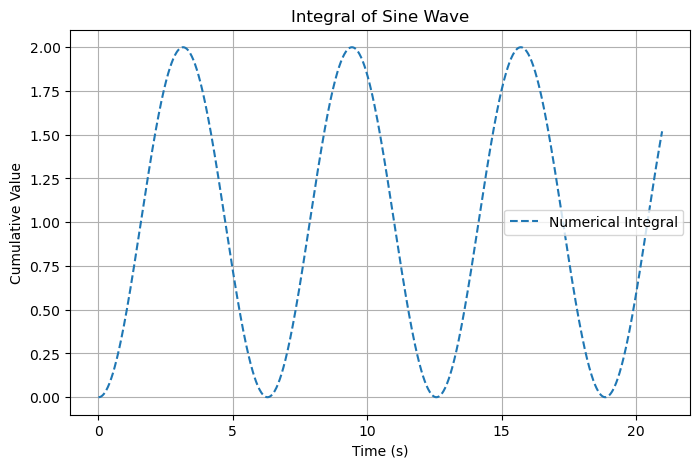

In [5]:
# Calculate the numerical integral of the sine wave
int_sin = np.zeros(len(sin))  # Initialize the integral array with zeros
for i in range(1, len(sin)):
    dt = ts[i] - ts[i-1]
    int_sin[i] = int_sin[i-1] + sin[i] * dt

# Plot the integral
plt.figure(figsize=(8, 5))
plt.plot(ts, int_sin, '--', label='Numerical Integral')
plt.title('Integral of Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Cumulative Value')
plt.grid(True)
plt.legend()
plt.show()

### 1.4 Effect of Noise on Derivatives and Integrals

- Real-world data often contains noise, which significantly impacts differentiation and integration.
- Differentiation amplifies noise, resulting in large variations in the calculated derivative.
- Integration, on the other hand, tends to smooth out noise due to the cumulative summation process.

We will calculate and plot the derivative and integral of the noisy sine wave to observe these effects.

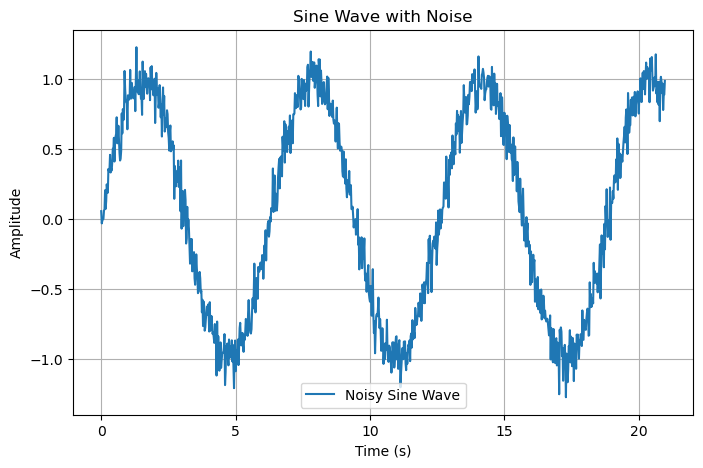

In [6]:
# Extract the noisy sine wave from the dataset
sin_noise = data['sin_noise'].values

# Plot the noisy sine wave
plt.figure(figsize=(8, 5))
plt.plot(ts, sin_noise, label='Noisy Sine Wave')
plt.title('Sine Wave with Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

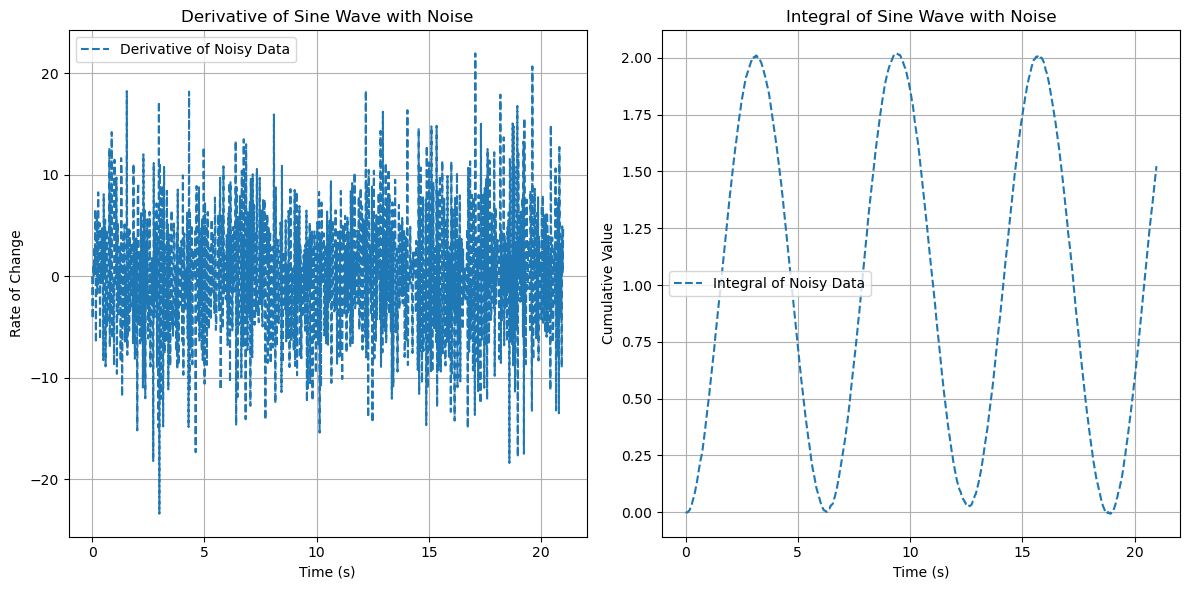

In [7]:
# Derivative of the noisy sine wave
dsin_noise = np.zeros(len(sin_noise))
for i in range(1, len(sin_noise)):
    dsin_noise[i] = (sin_noise[i] - sin_noise[i-1]) / (ts[i] - ts[i-1])

# Integral of the noisy sine wave
int_sin_noise = np.zeros(len(sin_noise))
for i in range(1, len(sin_noise)):
    int_sin_noise[i] = int_sin_noise[i-1] + sin_noise[i] * (ts[i] - ts[i-1])

# Plot the results
plt.figure(figsize=(12, 6))

# Plot noisy derivative
plt.subplot(1, 2, 1)
plt.plot(ts, dsin_noise, '--', label='Derivative of Noisy Data')
plt.title('Derivative of Sine Wave with Noise')
plt.xlabel('Time (s)')
plt.ylabel('Rate of Change')
plt.grid(True)
plt.legend()

# Plot noisy integral
plt.subplot(1, 2, 2)
plt.plot(ts, int_sin_noise, '--', label='Integral of Noisy Data')
plt.title('Integral of Sine Wave with Noise')
plt.xlabel('Time (s)')
plt.ylabel('Cumulative Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()